In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nselib import capital_market as cm
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.statespace.varmax import VARMAX
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =============================================================================
# 1. DATA COLLECTION
# =============================================================================

# Define dates as strings in DD-MM-YYYY format
start_date = '01-06-2021'
end_date = '05-01-2022'

# Fetch stock data from NSE
stk_data = cm.price_volume_data(symbol='TATACOFFEE', from_date=start_date, to_date=end_date)

print("Original Data Shape:", stk_data.shape)
print(stk_data.head())

Original Data Shape: (151, 13)
       Symbol Series         Date  PrevClose  OpenPrice  HighPrice  LowPrice  \
0  TATACOFFEE     EQ  05-Jan-2022     217.80     218.50      218.7    214.30   
1  TATACOFFEE     EQ  04-Jan-2022     214.05     214.90      220.8    212.45   
2  TATACOFFEE     EQ  03-Jan-2022     213.15     213.95      216.9    212.30   
3  TATACOFFEE     EQ  31-Dec-2021     208.50     208.90      216.2    208.40   
4  TATACOFFEE     EQ  30-Dec-2021     211.35     211.45      211.5    207.90   

   LastPrice  ClosePrice  AveragePrice TotalTradedQuantity        Turnover₹  \
0     214.65      214.85        215.72           13,50,483  29,13,25,687.40   
1     217.40      217.80        217.41           34,77,443  75,60,37,979.15   
2     214.30      214.05        214.76           15,25,259  32,75,66,528.25   
3     213.70      213.15        213.37           30,45,699  64,98,54,073.20   
4     208.80      208.50        209.36            9,77,484  20,46,47,553.50   

  No.ofTrades

In [3]:
# =============================================================================
# 2. DATA PREPROCESSING
# =============================================================================

# Select multiple columns for VARMAX (multivariate time series)
# VARMAX requires at least 2 endogenous variables
columns = ["OpenPrice", "HighPrice", "LowPrice", "ClosePrice"]
stk_data = stk_data[columns]

# Convert to numeric and handle missing values
stk_data = stk_data.apply(pd.to_numeric, errors='coerce')
stk_data = stk_data.dropna()
stk_data = stk_data.reset_index(drop=True)

print("\nProcessed Data Shape:", stk_data.shape)
print(stk_data.head())


Processed Data Shape: (151, 4)
   OpenPrice  HighPrice  LowPrice  ClosePrice
0     218.50      218.7    214.30      214.85
1     214.90      220.8    212.45      217.80
2     213.95      216.9    212.30      214.05
3     208.90      216.2    208.40      213.15
4     211.45      211.5    207.90      208.50


In [4]:

# =============================================================================
# 3. SCALING THE DATA
# =============================================================================

# Initialize MinMaxScaler
Ms = MinMaxScaler()

# Fit and transform all columns
data_scaled = Ms.fit_transform(stk_data)

# Convert back to DataFrame for easier handling
data_scaled_df = pd.DataFrame(data_scaled, columns=columns)

print("\nScaled Data Shape:", data_scaled_df.shape)
print(data_scaled_df.head())



Scaled Data Shape: (151, 4)
   OpenPrice  HighPrice  LowPrice  ClosePrice
0   0.682875   0.546667  0.732016    0.666932
1   0.632135   0.573333  0.702767    0.713831
2   0.618746   0.523810  0.700395    0.654213
3   0.547569   0.514921  0.638735    0.639905
4   0.583510   0.455238  0.630830    0.565978


In [5]:

# =============================================================================
# 4. TRAIN-TEST SPLIT
# =============================================================================

# Define test size
test_size = 28

# Split data
train_data = data_scaled_df[:-test_size]
test_data = data_scaled_df[-test_size:]

print(f"\nTraining Data Shape: {train_data.shape}")
print(f"Test Data Shape: {test_data.shape}")



Training Data Shape: (123, 4)
Test Data Shape: (28, 4)


In [6]:

# =============================================================================
# 5. VARMAX MODEL - ORDER SELECTION
# =============================================================================

# Define different VARMAX orders to test
# order = (p, q) where p = AR order, q = MA order
orders = [(1, 0), (1, 1), (2, 0), (2, 1), (3, 0), (3, 1)]

print("\n" + "="*60)
print("VARMAX ORDER SELECTION")
print("="*60)

results_dict = {}

for order in orders:
    try:
        # Fit VARMAX model
        # order=(p, q): p=autoregressive order, q=moving average order
        model = VARMAX(train_data, order=order, trend='c')
        model_fit = model.fit(disp=False, maxiter=500)
        
        # Store results
        results_dict[order] = {
            'AIC': model_fit.aic,
            'BIC': model_fit.bic,
            'HQIC': model_fit.hqic,
            'Log-Likelihood': model_fit.llf
        }
        
        print(f"\nOrder (p={order[0]}, q={order[1]}):")
        print(f"  AIC:  {model_fit.aic:.4f}")
        print(f"  BIC:  {model_fit.bic:.4f}")
        print(f"  HQIC: {model_fit.hqic:.4f}")
        
    except Exception as e:
        print(f"\nOrder {order}: Failed - {str(e)[:50]}")

# Select best order based on AIC
best_order = min(results_dict.keys(), key=lambda x: results_dict[x]['AIC'])
print(f"\n{'='*60}")
print(f"Best Order based on AIC: (p={best_order[0]}, q={best_order[1]})")
print(f"{'='*60}")



VARMAX ORDER SELECTION

Order (p=1, q=0):
  AIC:  -1794.2800
  BIC:  -1709.9144
  HQIC: -1760.0109

Order (p=1, q=1):
  AIC:  -1767.5999
  BIC:  -1638.2395
  HQIC: -1715.0540

Order (p=2, q=0):
  AIC:  -1779.8642
  BIC:  -1650.5037
  HQIC: -1727.3183

Order (p=2, q=1):
  AIC:  -1748.6719
  BIC:  -1574.3165
  HQIC: -1677.8492

Order (p=3, q=0):
  AIC:  -1760.3226
  BIC:  -1585.9671
  HQIC: -1689.4998

Order (p=3, q=1):
  AIC:  -1728.8746
  BIC:  -1509.5242
  HQIC: -1639.7750

Best Order based on AIC: (p=1, q=0)


In [7]:

# =============================================================================
# 6. FIT FINAL VARMAX MODEL WITH BEST ORDER
# =============================================================================

print("\nFitting Final VARMAX Model...")

# Fit the final model with best order
final_model = VARMAX(train_data, order=best_order, trend='c')
final_model_fit = final_model.fit(disp=False, maxiter=1000)

# Print model summary
print("\n" + "="*60)
print("VARMAX MODEL SUMMARY")
print("="*60)
print(final_model_fit.summary())



Fitting Final VARMAX Model...

VARMAX MODEL SUMMARY
                                            Statespace Model Results                                            
Dep. Variable:     ['OpenPrice', 'HighPrice', 'LowPrice', 'ClosePrice']   No. Observations:                  123
Model:                                                           VAR(1)   Log Likelihood                 927.140
                                                            + intercept   AIC                          -1794.280
Date:                                                  Wed, 01 Jul 2026   BIC                          -1709.914
Time:                                                          12:56:11   HQIC                         -1760.011
Sample:                                                               0                                         
                                                                  - 123                                         
Covariance Type:                           

In [8]:
# =============================================================================
# 7. IN-SAMPLE PREDICTIONS (FITTED VALUES)
# =============================================================================

# Get fitted values for training data
fitted_values = final_model_fit.fittedvalues

print("\nFitted Values Shape:", fitted_values.shape)



Fitted Values Shape: (123, 4)


In [9]:

# =============================================================================
# 8. OUT-OF-SAMPLE FORECASTING
# =============================================================================

# Forecast for test period
forecast = final_model_fit.forecast(steps=test_size)

print("\nForecast Shape:", forecast.shape)
print("\nForecasted Values (Scaled):")
print(forecast.head())



Forecast Shape: (28, 4)

Forecasted Values (Scaled):
     OpenPrice  HighPrice  LowPrice  ClosePrice
123   0.320441   0.233458  0.320133    0.280131
124   0.353585   0.268008  0.354023    0.317745
125   0.382262   0.298232  0.386297    0.353041
126   0.407020   0.323779  0.414805    0.383488
127   0.428362   0.345638  0.439685    0.409803


In [10]:

# =============================================================================
# 9. INVERSE TRANSFORM PREDICTIONS
# =============================================================================

# Convert forecasted values back to original scale
forecast_original = Ms.inverse_transform(forecast)
forecast_original_df = pd.DataFrame(forecast_original, columns=columns)

# Convert test data back to original scale
test_original = Ms.inverse_transform(test_data)
test_original_df = pd.DataFrame(test_original, columns=columns)

# Convert training data back to original scale
train_original = Ms.inverse_transform(train_data)
train_original_df = pd.DataFrame(train_original, columns=columns)

print("\nForecasted Values (Original Scale):")
print(forecast_original_df.head())



Forecasted Values (Original Scale):
    OpenPrice   HighPrice    LowPrice  ClosePrice
0  192.785272  194.034807  188.248411  190.520230
1  195.136865  196.755650  190.391945  192.886134
2  197.171502  199.135784  192.433293  195.106254
3  198.928048  201.147611  194.236443  197.021385
4  200.442266  202.869022  195.810074  198.676584


In [11]:
# =============================================================================
# 10. PERFORMANCE METRICS
# =============================================================================

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)

performance_results = []

for col in columns:
    actual = test_original_df[col].values
    predicted = forecast_original_df[col].values
    
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    mae = mean_absolute_error(actual, predicted)
    
    performance_results.append({
        'Variable': col,
        'RMSE': round(rmse, 4),
        'MAPE (%)': round(mape, 4),
        'MAE': round(mae, 4)
    })
    
    print(f"\n{col}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAPE: {mape:.4f}%")
    print(f"  MAE:  {mae:.4f}")

# Create performance DataFrame
performance_df = pd.DataFrame(performance_results)
print("\n" + "="*60)
print("PERFORMANCE SUMMARY TABLE")
print("="*60)
print(performance_df)


PERFORMANCE METRICS

OpenPrice:
  RMSE: 25.9971
  MAPE: 13.4640%
  MAE:  24.0972

HighPrice:
  RMSE: 26.2546
  MAPE: 13.1534%
  MAE:  23.8989

LowPrice:
  RMSE: 24.9891
  MAPE: 13.0648%
  MAE:  22.9478

ClosePrice:
  RMSE: 25.2826
  MAPE: 12.8944%
  MAE:  23.0019

PERFORMANCE SUMMARY TABLE
     Variable     RMSE  MAPE (%)      MAE
0   OpenPrice  25.9971   13.4640  24.0972
1   HighPrice  26.2546   13.1534  23.8989
2    LowPrice  24.9891   13.0648  22.9478
3  ClosePrice  25.2826   12.8944  23.0019


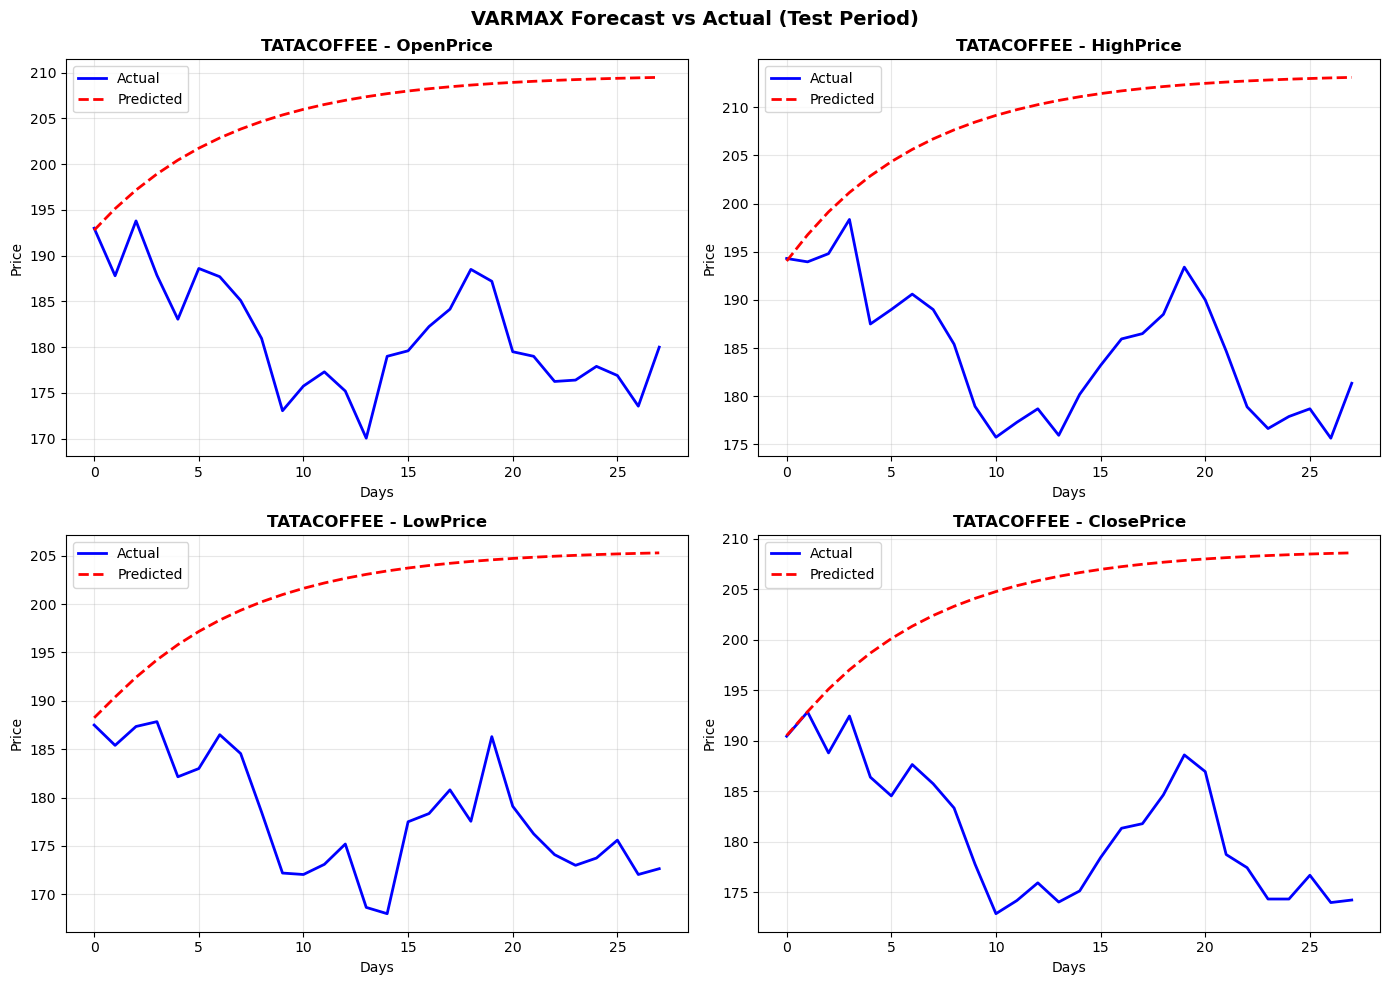

In [12]:
# =============================================================================
# 11. VISUALIZATION - ALL VARIABLES
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(columns):
    ax = axes[idx]
    
    # Plot actual test values
    ax.plot(range(test_size), test_original_df[col].values, 
            color='blue', label='Actual', linewidth=2)
    
    # Plot predicted values
    ax.plot(range(test_size), forecast_original_df[col].values, 
            color='red', label='Predicted', linewidth=2, linestyle='--')
    
    ax.set_title(f'TATACOFFEE - {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('VARMAX Forecast vs Actual (Test Period)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('varmax_forecast_all_variables.png', dpi=300, bbox_inches='tight')
plt.show()


CLOSE PRICE ANALYSIS


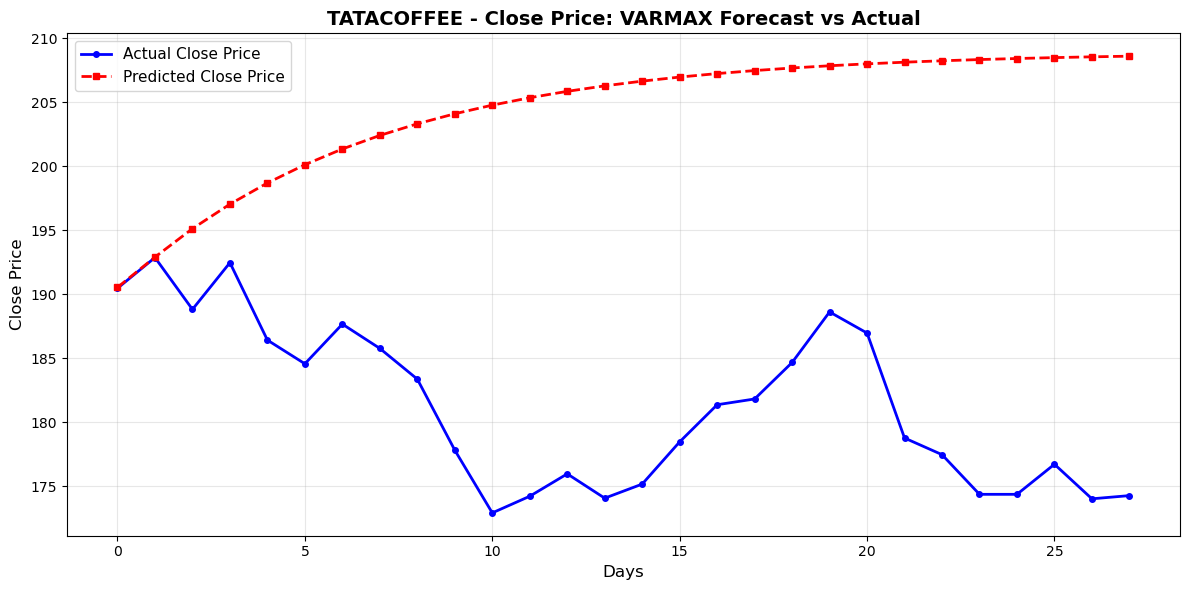

In [13]:
# =============================================================================
# 12. FOCUS ON CLOSE PRICE
# =============================================================================

print("\n" + "="*60)
print("CLOSE PRICE ANALYSIS")
print("="*60)

plt.figure(figsize=(12, 6))

# Plot actual ClosePrice
plt.plot(range(test_size), test_original_df['ClosePrice'].values, 
         color='blue', label='Actual Close Price', linewidth=2, marker='o', markersize=4)

# Plot predicted ClosePrice
plt.plot(range(test_size), forecast_original_df['ClosePrice'].values, 
         color='red', label='Predicted Close Price', linewidth=2, linestyle='--', marker='s', markersize=4)

plt.title('TATACOFFEE - Close Price: VARMAX Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('varmax_close_price_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:

# =============================================================================
# 13. FUTURE FORECASTING (BEYOND TEST DATA)
# =============================================================================

print("\n" + "="*60)
print("FUTURE FORECASTING")
print("="*60)

# Fit model on entire dataset for future forecasting
full_model = VARMAX(data_scaled_df, order=best_order, trend='c')
full_model_fit = full_model.fit(disp=False, maxiter=1000)

# Forecast next 5 days
future_steps = 5
future_forecast = full_model_fit.forecast(steps=future_steps)

# Inverse transform to original scale
future_forecast_original = Ms.inverse_transform(future_forecast)
future_forecast_df = pd.DataFrame(future_forecast_original, columns=columns)
future_forecast_df.index = [f'Day {i+1}' for i in range(future_steps)]

print(f"\nNext {future_steps} Days Forecast:")
print(future_forecast_df)

# Save future forecast to CSV
future_forecast_df.to_csv('varmax_future_forecast.csv')
print("\nFuture forecast saved to 'varmax_future_forecast.csv'")


FUTURE FORECASTING

Next 5 Days Forecast:
        OpenPrice   HighPrice    LowPrice  ClosePrice
Day 1  180.362656  184.115219  176.026157  179.901436
Day 2  181.680306  184.192280  177.234031  180.255094
Day 3  182.976419  185.396159  178.763614  181.606914
Day 4  184.178506  186.607068  180.052062  182.862288
Day 5  185.316432  187.779664  181.219402  184.027607

Future forecast saved to 'varmax_future_forecast.csv'


In [15]:
# =============================================================================
# 14. SAVE ALL RESULTS
# =============================================================================

# Save test period predictions
comparison_df = pd.DataFrame({
    'Actual_Open': test_original_df['OpenPrice'].values,
    'Predicted_Open': forecast_original_df['OpenPrice'].values,
    'Actual_High': test_original_df['HighPrice'].values,
    'Predicted_High': forecast_original_df['HighPrice'].values,
    'Actual_Low': test_original_df['LowPrice'].values,
    'Predicted_Low': forecast_original_df['LowPrice'].values,
    'Actual_Close': test_original_df['ClosePrice'].values,
    'Predicted_Close': forecast_original_df['ClosePrice'].values
})
comparison_df.to_csv('varmax_test_predictions.csv', index=False)
print("Test predictions saved to 'varmax_test_predictions.csv'")

# Save performance metrics
performance_df.to_csv('varmax_performance_metrics.csv', index=False)
print("Performance metrics saved to 'varmax_performance_metrics.csv'")


Test predictions saved to 'varmax_test_predictions.csv'
Performance metrics saved to 'varmax_performance_metrics.csv'


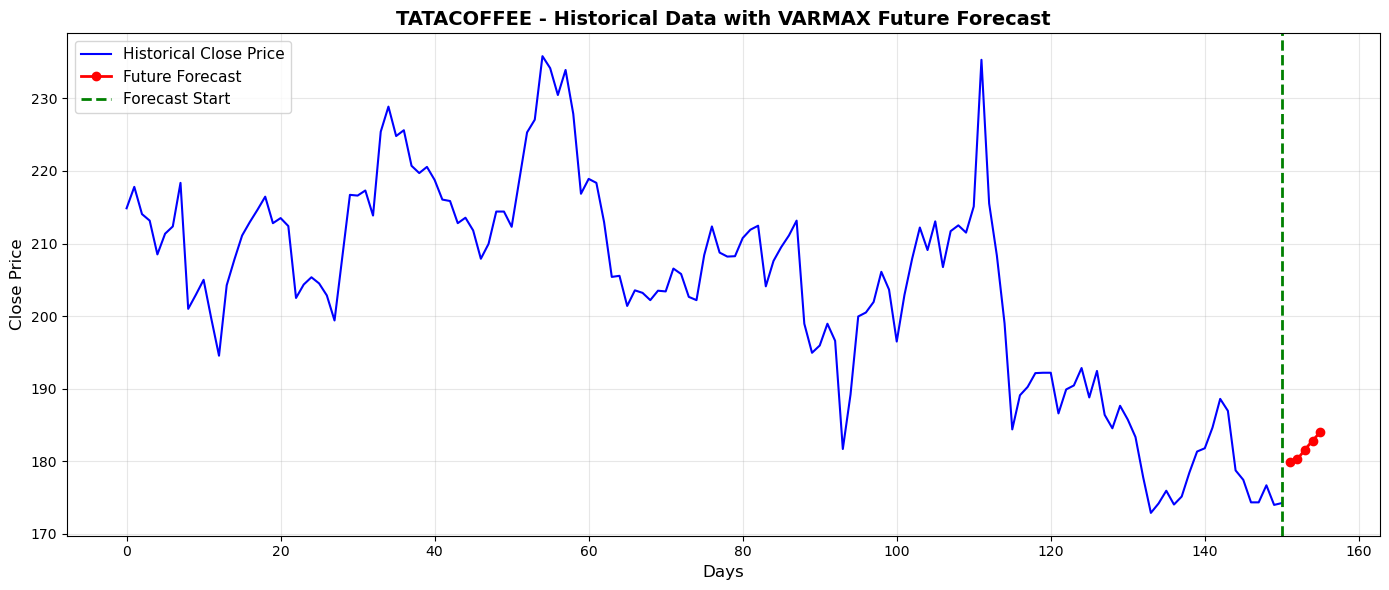


VARMAX ANALYSIS COMPLETE


In [16]:
# =============================================================================
# 15. PLOT FULL SERIES WITH FORECAST
# =============================================================================

plt.figure(figsize=(14, 6))

# Original data length
original_length = len(stk_data)

# Plot historical data
plt.plot(range(original_length), stk_data['ClosePrice'].values, 
         color='blue', label='Historical Close Price', linewidth=1.5)

# Plot future forecast
forecast_indices = range(original_length, original_length + future_steps)
plt.plot(forecast_indices, future_forecast_df['ClosePrice'].values, 
         color='red', label='Future Forecast', linewidth=2, marker='o', markersize=6)

# Add vertical line to separate historical and forecast
plt.axvline(x=original_length-1, color='green', linestyle='--', linewidth=2, label='Forecast Start')

plt.title('TATACOFFEE - Historical Data with VARMAX Future Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('varmax_historical_with_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("VARMAX ANALYSIS COMPLETE")
print("="*60)